# Improting Required libraries

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from numpy.random import rand
from sklearn.model_selection import RandomizedSearchCV
import joblib

In [107]:
df = pd.read_csv("/content/Life Expectancy Data.csv")

# Data Exploration

In [108]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [110]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [111]:
df.describe(include="object")

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [112]:
df.isna().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [113]:
df.duplicated().sum()

np.int64(0)

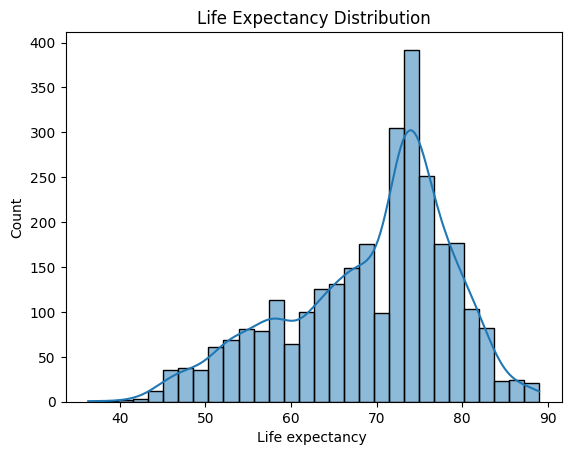

In [114]:
sns.histplot(df["Life expectancy "],kde=True)
plt.title("Life Expectancy Distribution")
plt.show()

# Data Visualization (EDA)

In [115]:
for col in df.select_dtypes(include="object").columns:
  print(df[col].value_counts())
  print("="*50)

Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Monaco                    1
Marshall Islands          1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64
Status
Developing    2426
Developed      512
Name: count, dtype: int64


In [116]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

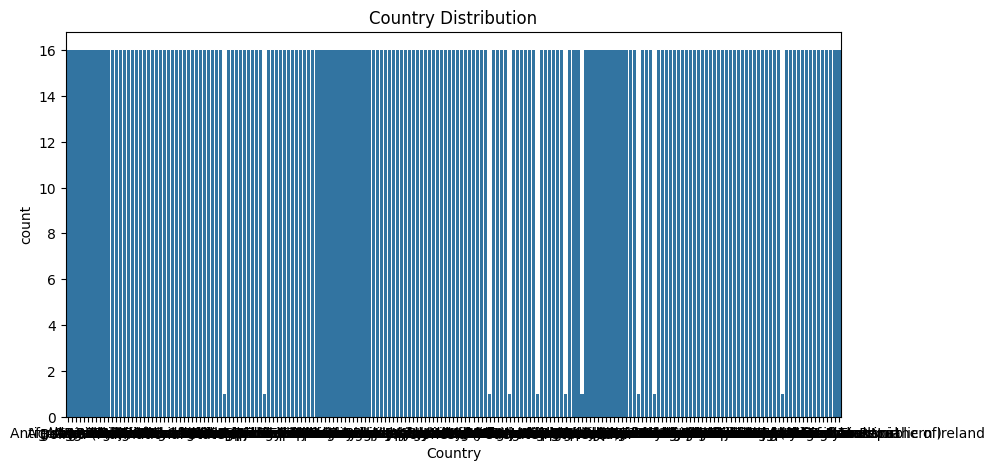

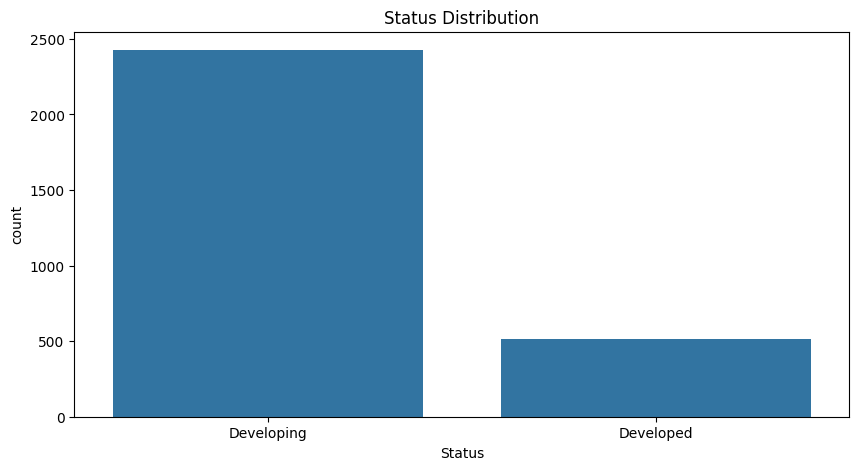

In [117]:
for col in cat_cols:
  plt.figure(figsize=(10,5))
  sns.countplot(x=col,data=df)
  plt.title(f"{col} Distribution")
  plt.show()

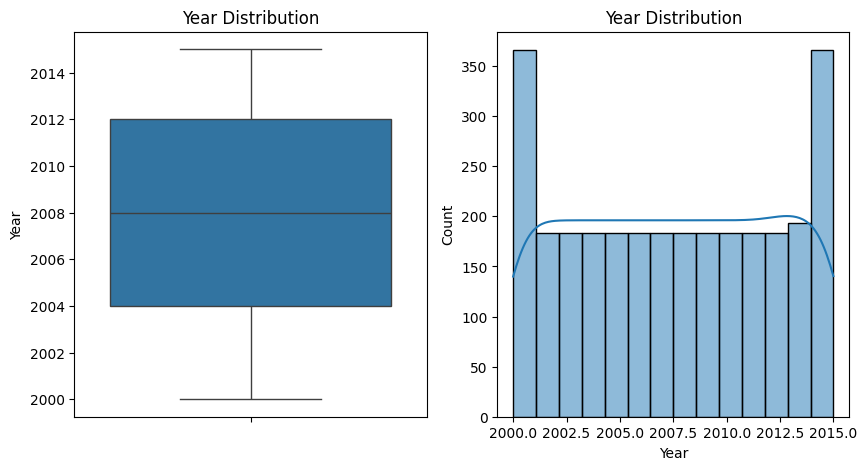

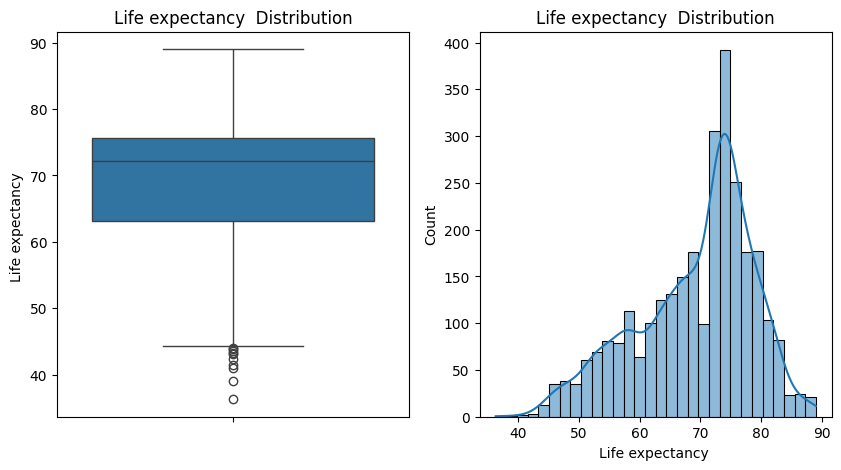

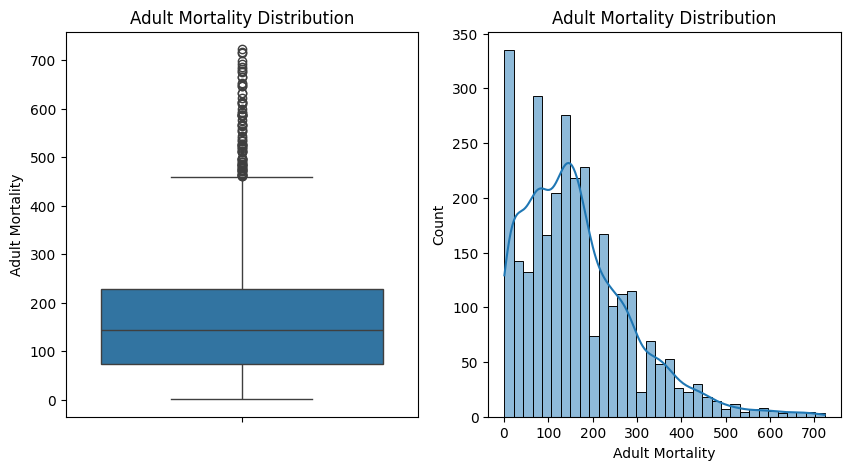

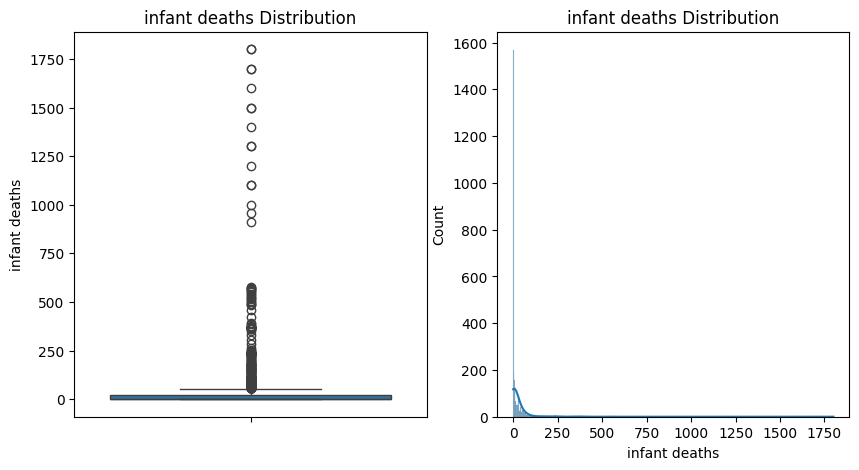

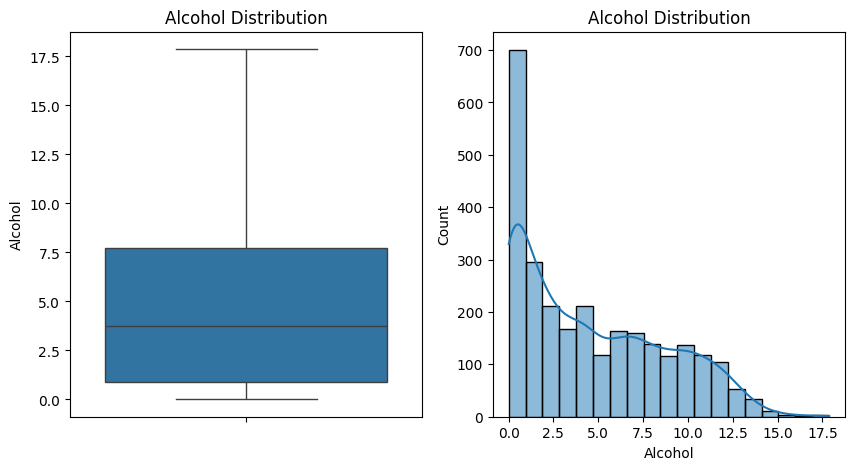

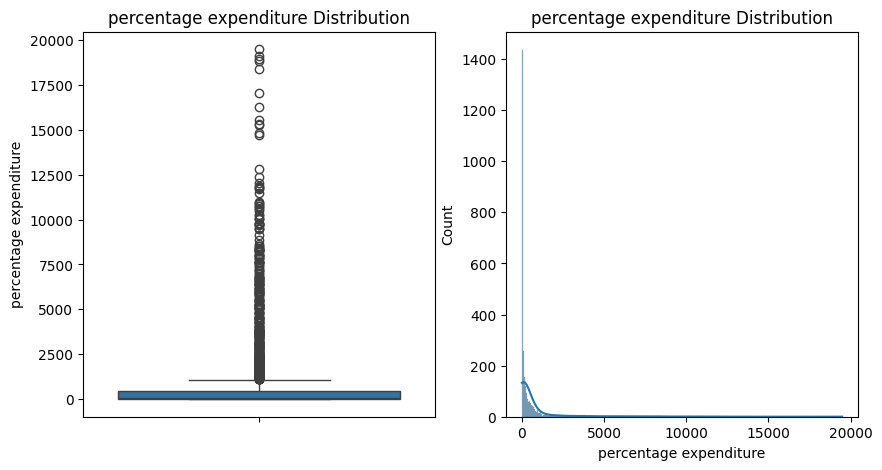

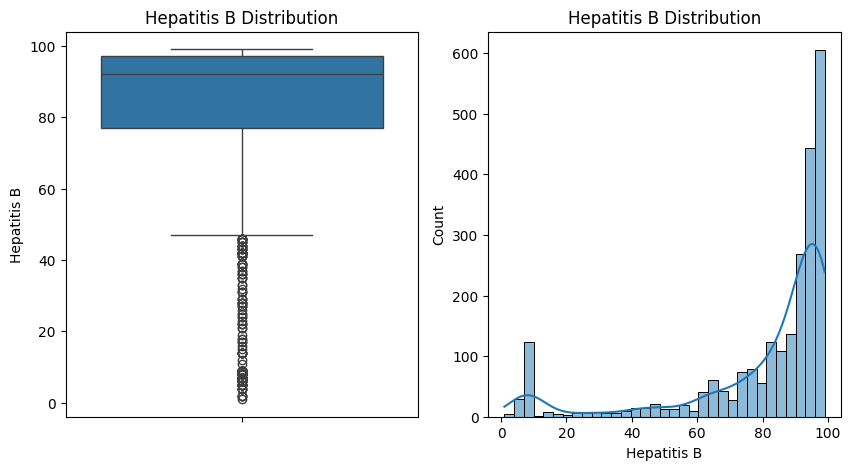

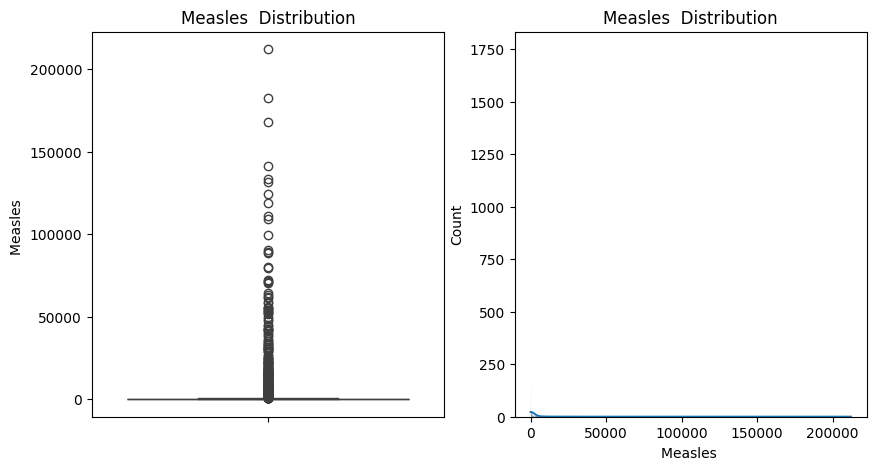

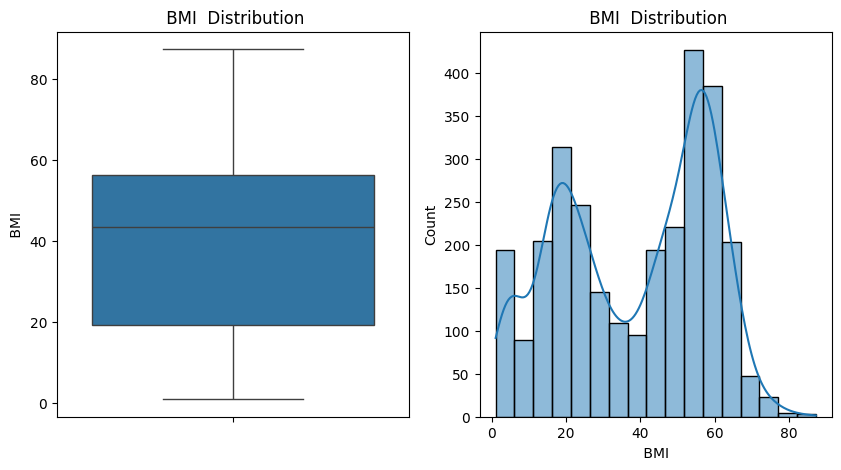

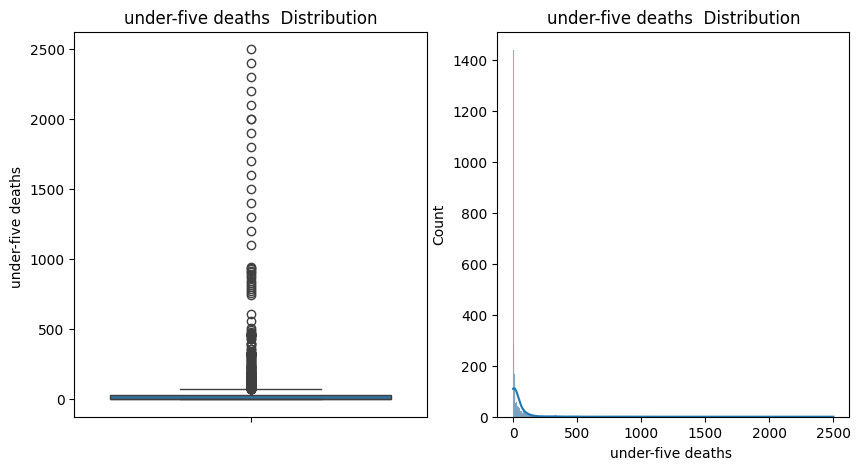

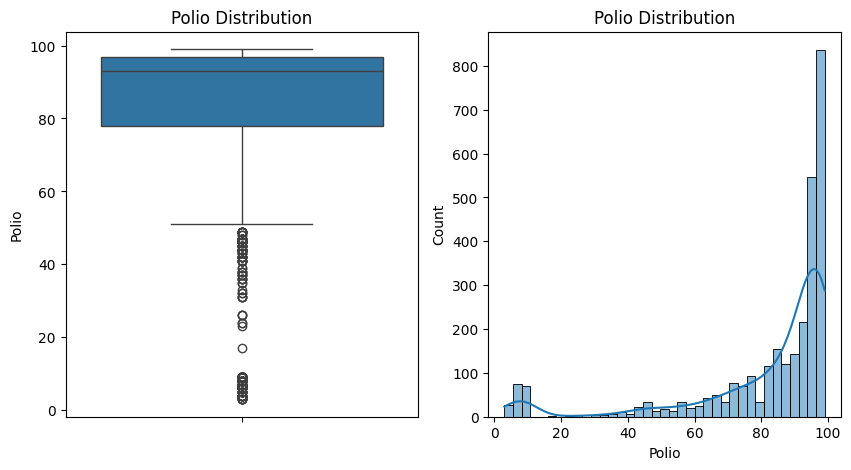

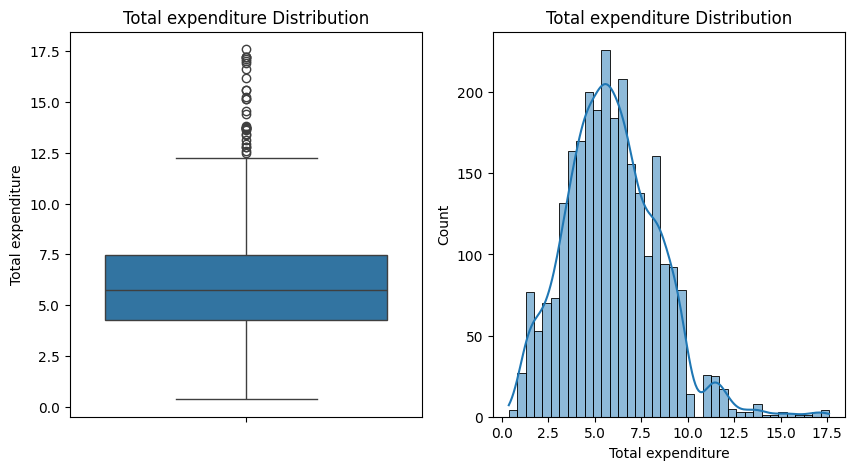

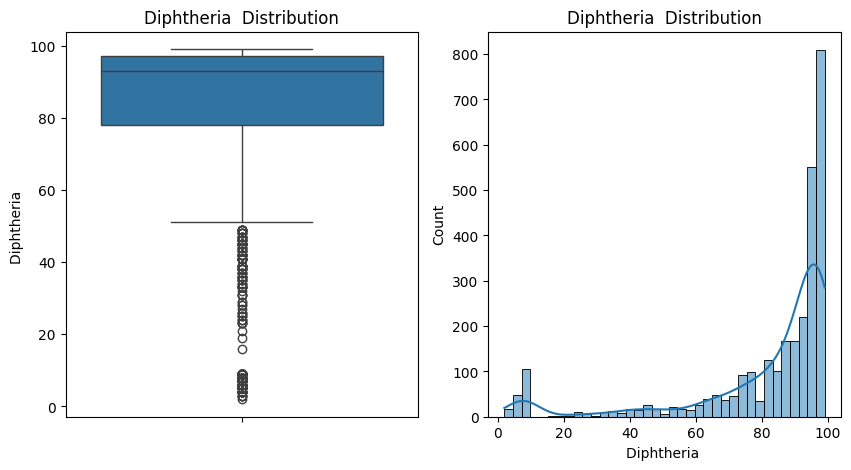

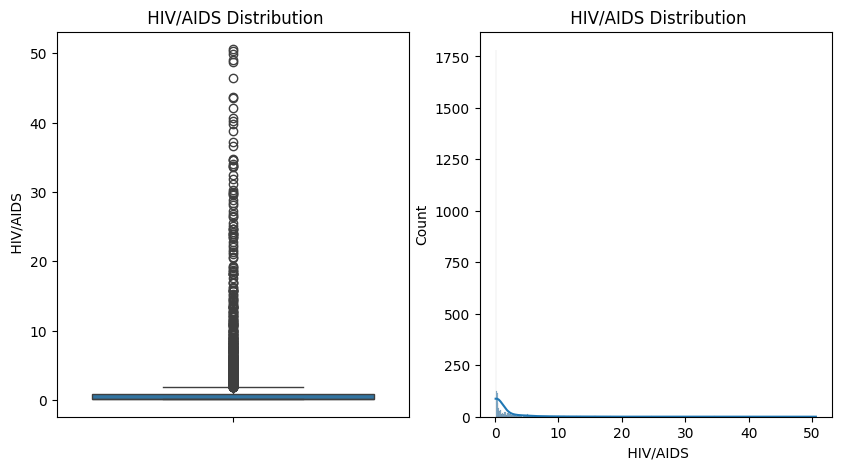

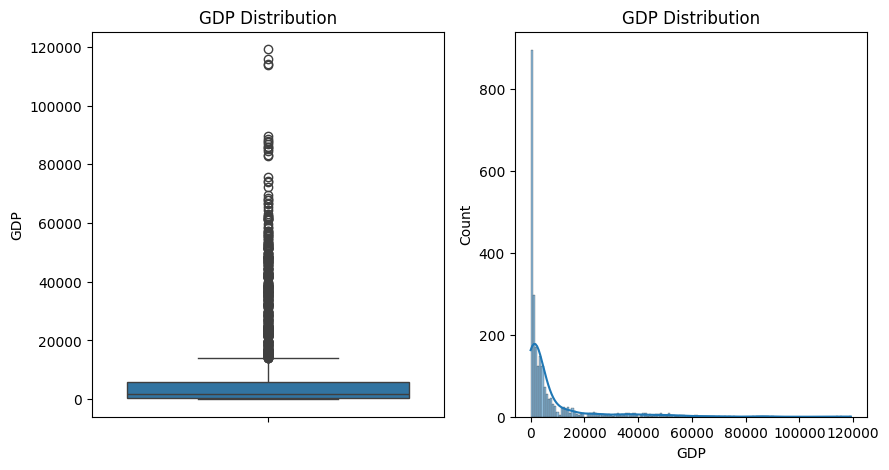

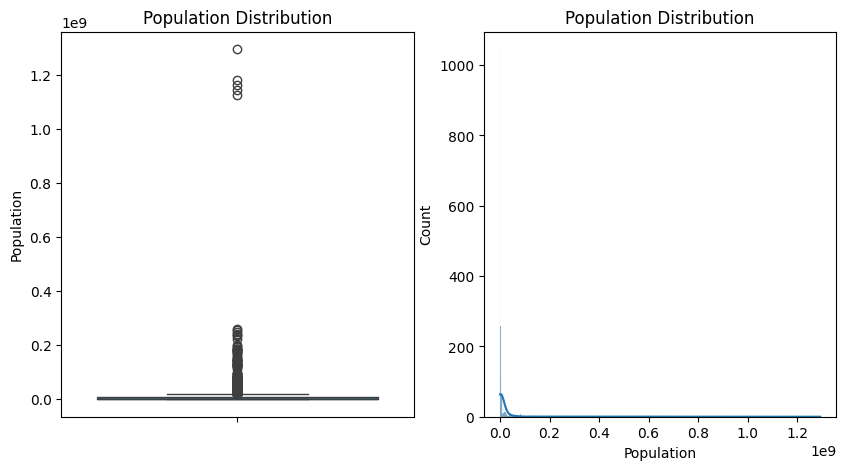

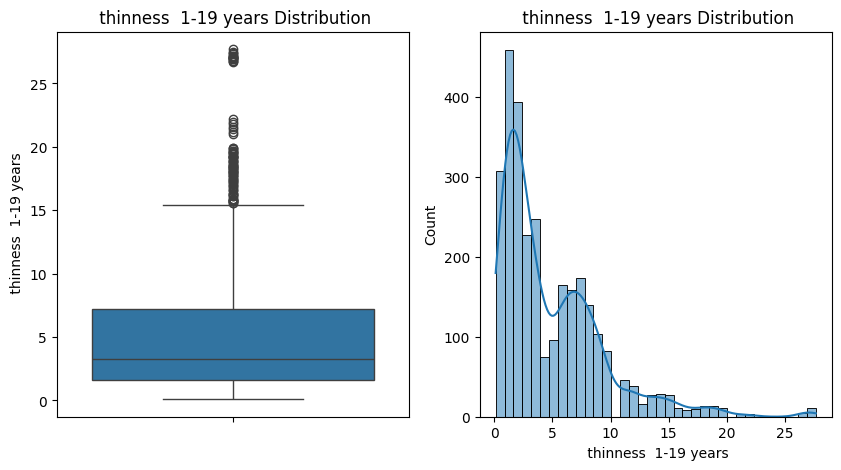

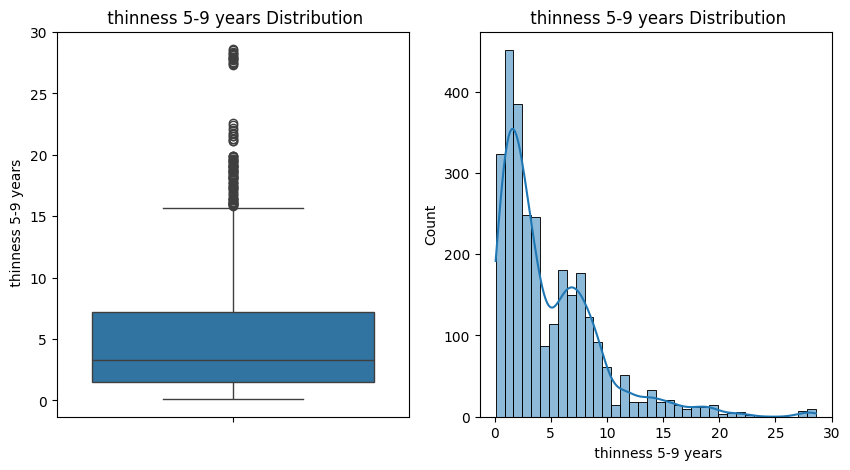

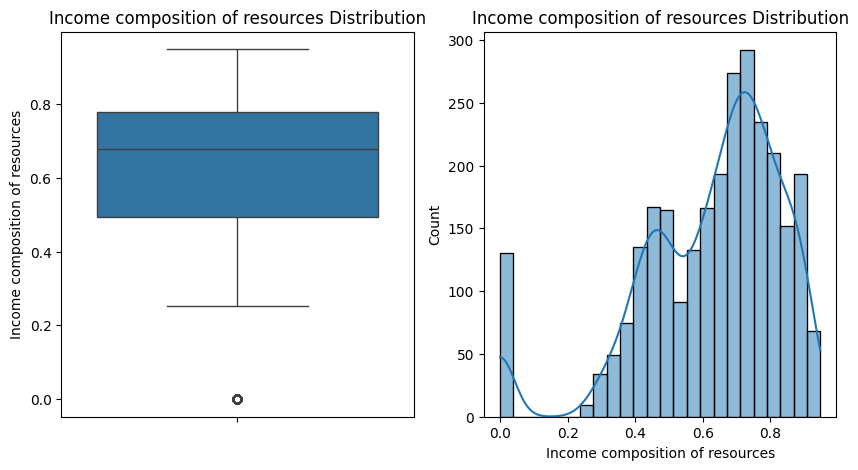

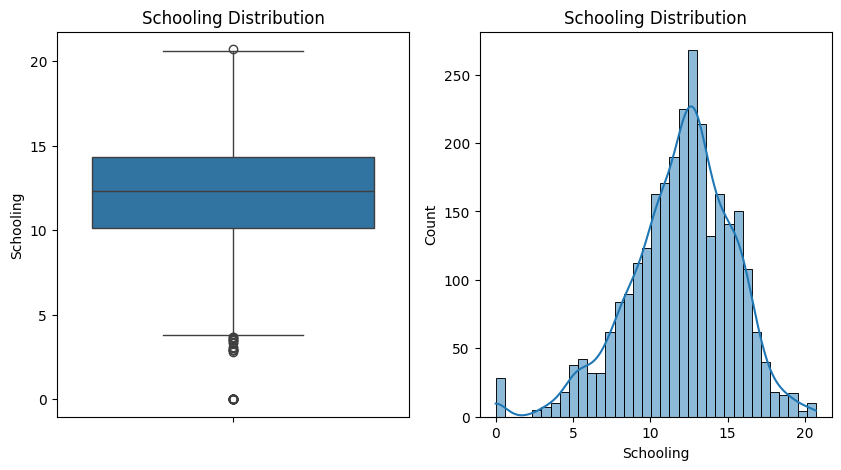

In [118]:
for col in num_cols:
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  sns.boxplot(df[col])
  plt.title(f"{col} Distribution")
  plt.subplot(1,2,2)
  sns.histplot(df[col],kde=True)
  plt.title(f"{col} Distribution")
  plt.show()

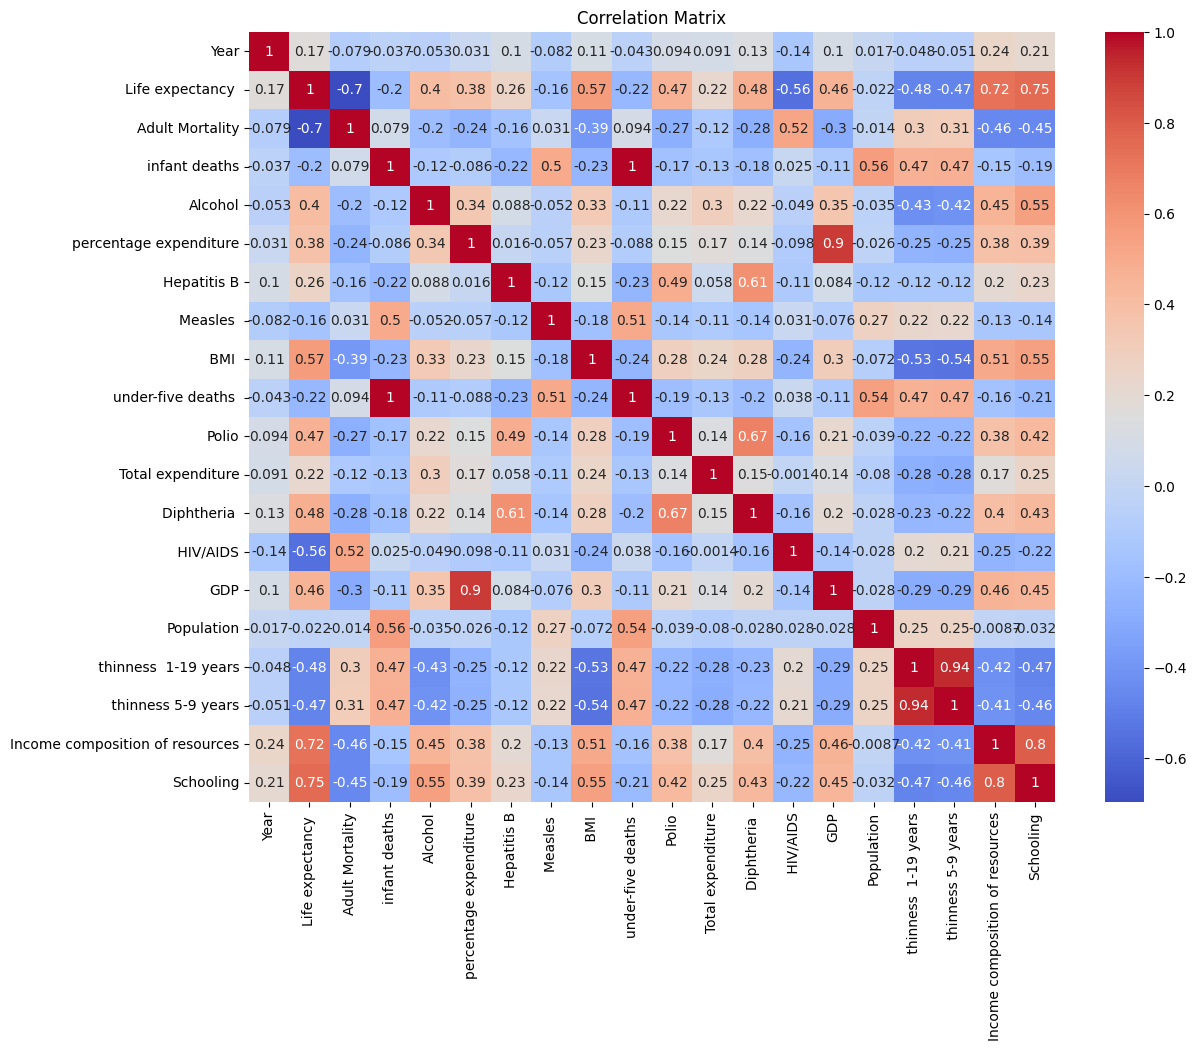

In [119]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(13,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Data Cleaning

In [120]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [121]:
df.columns = df.columns.str.strip()

In [122]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [123]:
df = df.drop(columns=['under-five deaths','GDP','thinness 5-9 years','Adult Mortality']) # drop features with corr higher than 0.9

In [124]:
(df.select_dtypes(include=np.number) < 0).sum()

,0
Year,0
Life expectancy,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0
BMI,0
Polio,0
Total expenditure,0


In [125]:
for col in df.select_dtypes(include=np.number).columns:
  df[col] = df[col].fillna(df[col].median())

In [126]:
df.isna().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0
BMI,0


# Outliers

In [127]:
outliers_cols =['Life expectancy','Alcohol','Income composition of resources','Schooling',
            'percentage expenditure','Measles','infant deaths','Hepatitis B','Polio',
            'Total expenditure','Diphtheria','HIV/AIDS','Population','thinness  1-19 years']
for col in outliers_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(f'{col}: {len(outliers)} outliers : ({len(outliers)/len(df)*100:.2f}%)')

Life expectancy: 17 outliers : (0.58%)
Alcohol: 3 outliers : (0.10%)
Income composition of resources: 130 outliers : (4.42%)
Schooling: 77 outliers : (2.62%)
percentage expenditure: 389 outliers : (13.24%)
Measles: 542 outliers : (18.45%)
infant deaths: 315 outliers : (10.72%)
Hepatitis B: 322 outliers : (10.96%)
Polio: 279 outliers : (9.50%)
Total expenditure: 51 outliers : (1.74%)
Diphtheria: 298 outliers : (10.14%)
HIV/AIDS: 542 outliers : (18.45%)
Population: 452 outliers : (15.38%)
thinness  1-19 years: 100 outliers : (3.40%)


In [128]:
skewed_cols = ['percentage expenditure','Measles','HIV/AIDS','Population']
for col in skewed_cols:
  df[col] = np.log1p(df[col])

mild_outliers_cols =['Life expectancy','Alcohol','Income composition of resources','Schooling','infant deaths','Hepatitis B','Polio','Total expenditure','Diphtheria','thinness  1-19 years']
for col in mild_outliers_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr
  df[col] = df[col].clip(lower,upper)

# Split Data

In [129]:
x = df.drop(columns=['Life expectancy'])
y = df['Life expectancy']

In [130]:
x = x.drop('Country',axis=1)

In [131]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)

# Data preprocessing

In [132]:
cat_cols = x.select_dtypes(include='object').columns.tolist()
num_cols = x.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OrdinalEncoder(),cat_cols),
        ('num',StandardScaler(),num_cols)
    ]
)

# Training models

In [133]:
def build_pipeline(model):
  pipeline = Pipeline([
      ('preprocessor',preprocessor),
      ('model',model)
  ])
  return pipeline

In [134]:
results = []

In [135]:
def evaluate_model(pipeline,x_train,x_test,y_train,y_test):
  pipeline.fit(x_train,y_train)
  cv = cross_val_score(pipeline,x_train,y_train,cv=5,scoring='r2')
  y_pred = pipeline.predict(x_test)
  results.append({
      'Model':pipeline.named_steps["model"].__class__.__name__,
      'Train Score':pipeline.score(x_train,y_train),
      'MSE':mean_squared_error(y_test,y_pred),
      'MAE':mean_absolute_error(y_test,y_pred),
      'RMSE':np.sqrt(mean_squared_error(y_test,y_pred)),
      'R2 Score':r2_score(y_test,y_pred),
      'Cross Validation Score':cv.mean()
  })
  print(pipeline.named_steps["model"].__class__.__name__)
  print("="*50)
  print("train score :", pipeline.score(x_train,y_train))
  print("cross validation score :", cv.mean())
  print("R2 score :", r2_score(y_test,y_pred))
  print("MSE :", mean_squared_error(y_test,y_pred))
  print("MAE :", mean_absolute_error(y_test,y_pred))
  print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred)))
  print("="*50)
  print()


In [136]:
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    GradientBoostingRegressor(random_state=42),
    AdaBoostRegressor(random_state=42),
    SVR(),
    KNeighborsRegressor(),
    MLPRegressor(random_state=42, max_iter=1000)
]

In [137]:
for model in models:
  pipeline = build_pipeline(model)
  evaluate_model(pipeline,x_train,x_test,y_train,y_test)

LinearRegression
train score : 0.8484503874031051
cross validation score : 0.8445956682993726
R2 score : 0.8500904182524516
MSE : 12.97332737559651
MAE : 2.691254650952721
RMSE : 3.601850548759139

Ridge
train score : 0.8484502350304991
cross validation score : 0.8445989716376564
R2 score : 0.8501301843311146
MSE : 12.969885978783005
MAE : 2.690751335116247
RMSE : 3.601372790865034

Lasso
train score : 0.8139341656646993
cross validation score : 0.8102467972035539
R2 score : 0.8203017514853057
MSE : 15.551268835693033
MAE : 2.9583708044623607
RMSE : 3.9435097103586587

DecisionTreeRegressor
train score : 1.0
cross validation score : 0.8877957917411411
R2 score : 0.9118954191103309
MSE : 7.62465986394558
MAE : 1.6629251700680274
RMSE : 2.761278664667074

RandomForestRegressor
train score : 0.9934305472134283
cross validation score : 0.9457603247774407
R2 score : 0.9594967195819811
MSE : 3.5051950017006757
MAE : 1.269379251700679
RMSE : 1.8722166011711026

GradientBoostingRegressor
train

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce

MLPRegressor
train score : 0.959604750025068
cross validation score : 0.9088286457023738
R2 score : 0.9317022002019916
MSE : 5.910560922680999
MAE : 1.79615642129128
RMSE : 2.43116451987129



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


# Choose best model

In [138]:
results_df = pd.DataFrame(results)
results_df.columns = ['Model','Train Score','MSE','MAE','RMSE','R2 Score','Cross Validation Score']
results_df

,Model,Train Score,MSE,MAE,RMSE,R2 Score,Cross Validation Score
0,LinearRegression,0.848450,12.973327,2.691255,3.601851,0.850090,0.844596
1,Ridge,0.848450,12.969886,2.690751,3.601373,0.850130,0.844599
2,Lasso,0.813934,15.551269,2.958371,3.943510,0.820302,0.810247
3,DecisionTreeRegressor,1.000000,7.624660,1.662925,2.761279,0.911895,0.887796
4,RandomForestRegressor,0.993431,3.505195,1.269379,1.872217,0.959497,0.945760
5,GradientBoostingRegressor,0.940631,6.608280,1.904118,2.570658,0.923640,0.914366
6,AdaBoostRegressor,0.890466,9.956866,2.528784,3.155450,0.884946,0.870210
7,SVR,0.888080,9.331530,2.221907,3.054755,0.892172,0.864638
8,KNeighborsRegressor,0.948477,6.762188,1.822109,2.600421,0.921861,0.905032
9,MLPRegressor,0.959605,5.910561,1.796156,2.431165,0.931702,0.908829


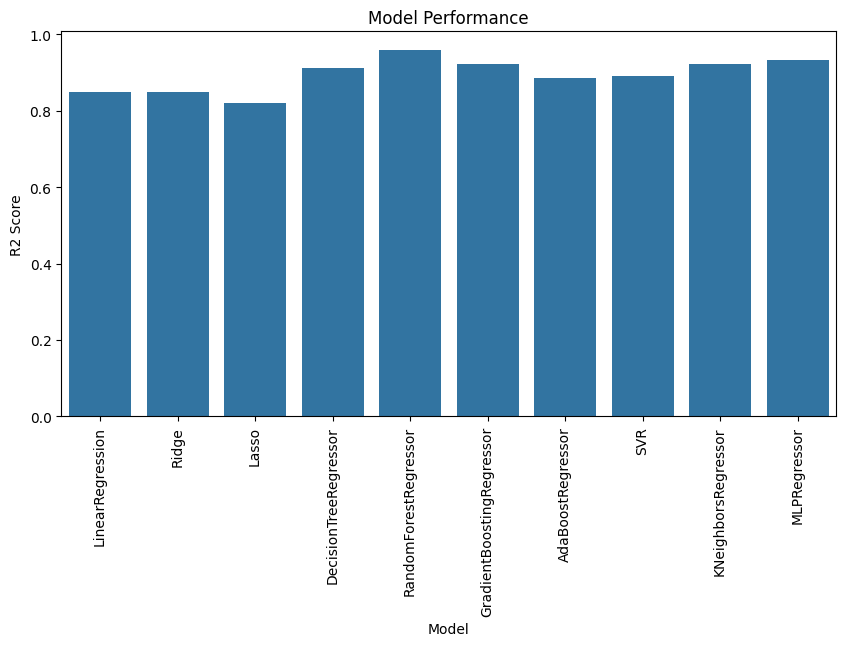

In [139]:
#from seaborn.distributions import kdeplot
plt.figure(figsize=(10,5))
sns.barplot(x='Model',y='R2 Score',data=results_df)
plt.title("Model Performance")
plt.xticks(rotation=90)
plt.show()

In [140]:
rf_pipeline = build_pipeline(RandomForestRegressor(random_state=42))
rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OrdinalEncoder(),
                                                  ['Status']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'infant deaths',
                                                   'Alcohol',
                                                   'percentage expenditure',
                                                   'Hepatitis B', 'Measles',
                                                   'BMI', 'Polio',
                                                   'Total expenditure',
                                                   'Diphtheria', 'HIV/AIDS',
                                                   'Population',
                                                   'thinness  1-19 years',
                                                   'Income composition of '
                                                   'resources',
                                                   'Schooling'])])),
                ('model', RandomForestRegressor(random_state=42))])

# Hyperparameter Tuning

In [141]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}
random_search = RandomizedSearchCV(rf_pipeline, param_grid,scoring="r2",cv=5,n_jobs=-1,random_state=42)
random_search.fit(x_train,y_train)
print("Best Parameters: ", random_search.best_params_)
print("Best Score: ", random_search.best_score_)

Best Parameters:  {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 20}
Best Score:  0.9457209643586324


In [142]:
best_model = random_search.best_estimator_
best_model.fit(x_train,y_train)
y_pred = best_model.predict(x_test)
print("Train Score: ", best_model.score(x_train,y_train))
print("R2 Score: ", r2_score(y_test,y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,y_pred)))


Train Score:  0.9936664524087067
R2 Score:  0.9604964923644053
MSE:  3.4186736502540342
MAE:  1.258291057904483
RMSE:  1.8489655622141896


# Feature Importance

In [143]:
rf_model = best_model.named_steps["model"]
feature_importances = pd.DataFrame(rf_model.feature_importances_,index=x_train.columns,columns=["Importance"])
feature_importances.sort_values(by="Importance",ascending=False,inplace=True)
feature_importances

,Importance
HIV/AIDS,0.623072
Income composition of resources,0.201445
infant deaths,0.039433
BMI,0.023799
thinness 1-19 years,0.022334
Schooling,0.018971
Total expenditure,0.013396
Alcohol,0.012464
Status,0.011527
percentage expenditure,0.006982


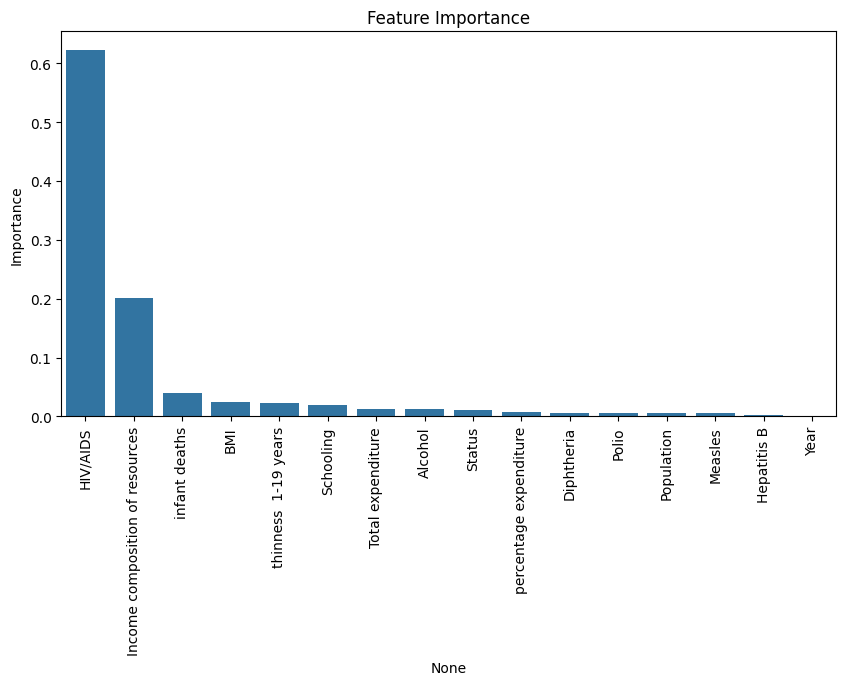

In [144]:
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importances.index,y=feature_importances["Importance"])
plt.title("Feature Importance")
plt.xticks(rotation=90)
plt.show()

# Residual Analysis

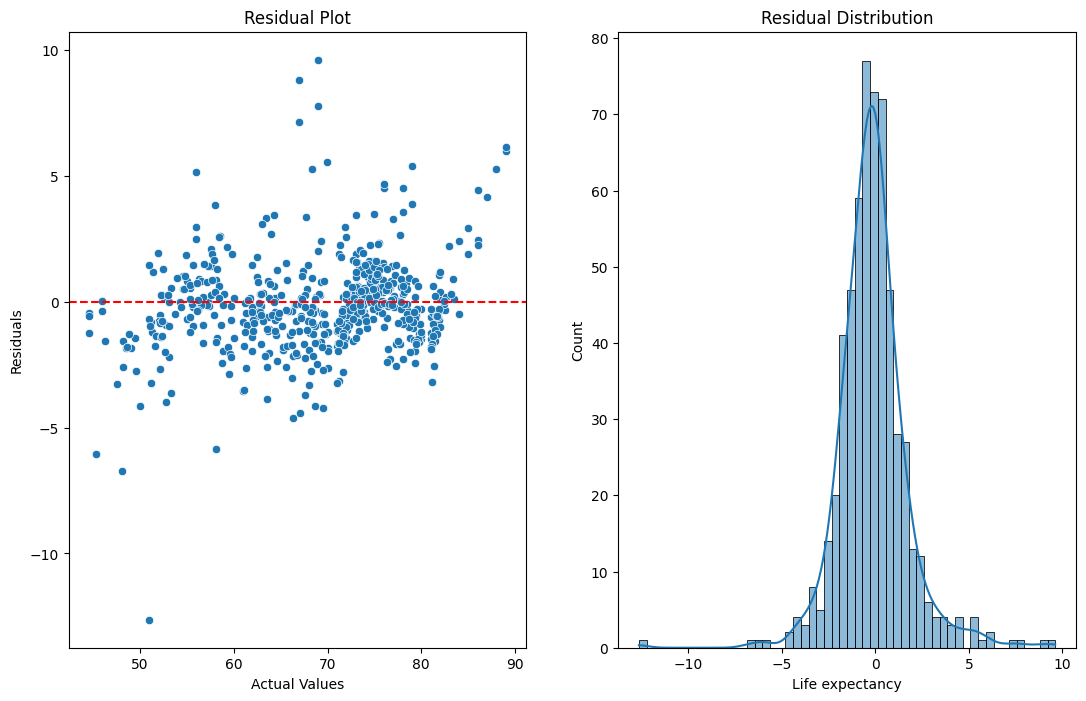

In [145]:
residuals = y_test - y_pred
plt.figure(figsize=(13,8))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test,y=residuals)
plt.axhline(y=0,color="red",linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.subplot(1,2,2)
sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.show()

# Saving Model

In [146]:
joblib.dump(best_model,"life_expectancy_model.pkl")

['life_expectancy_model.pkl']

In [147]:
input_data = pd.DataFrame({
    "Year": [2015],
    "Status": ["Developing"],
    "infant deaths": [30],
    "Alcohol": [4.5],
    "percentage expenditure": [120.5],
    "Hepatitis B": [85],
    "Measles": [10],
    "BMI": [25.6],
    "Polio": [90],
    "Total expenditure": [5.2],
    "Diphtheria": [88],
    "HIV/AIDS": [0.1],
    "Population": [1000000],
    "thinness  1-19 years": [3.5],
    "Income composition of resources": [0.65],
    "Schooling": [12.5]
})

In [148]:
pipeline = joblib.load("life_expectancy_model.pkl")
prediction = pipeline.predict(input_data)
print("Predicted Life Expectancy:", prediction[0])

Predicted Life Expectancy: 72.81733333333332
